In [2]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.optimize import least_squares
import surfinBH
import gwsurrogate as gws
import sympy as sp
from IPython.display import display, Math
import lal
from tqdm.auto import tqdm
lal.swig_redirect_standard_output_error(True)

True

In [3]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.50_chi1=0.20_chi2=0.20_th1=45_th2=45_dphi=90.csv'

In [4]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


### 1PN binding energy and total angular momentum

In this cell we construct the conservative orbital binding energy and the total angular momentum of a compact binary system up to 1PN order, keeping explicit powers of the speed of light $c$. The PN bookkeeping parameter is introduced as

$$
\epsilon = \frac{1}{c}.
$$

The standard dimensionless PN expansion parameter is

$$
x_{\rm PN} = \left(\frac{Gm\Omega}{c^3}\right)^{2/3},
$$

where $\Omega$ is the orbital frequency and $m=m_1+m_2$ is the total mass. In the symbolic calculation we introduce the rescaled variable $X$, defined by

$$
X = c^2 x_{\rm PN}.
$$

Equivalently,

$$
x_{\rm PN} = \frac{X}{c^2} = X\epsilon^2.
$$

This replacement is useful because it allows one to keep track explicitly of the powers of $1/c$ in the PN expansion.

The non-spinning binding energy up to 1PN order is

$$
E_{\rm bind}(X)
=

-\frac{\mu X}{2}
\left[
1+
\left(
-\frac{3}{4}


\frac{\nu}{12}
\right)
\frac{X}{c^2}
\right].
$$

The mass parameters are

$$
m = m_1+m_2,
\qquad
\mu = \frac{m_1m_2}{m},
\qquad
\nu = \frac{\mu}{m}.
$$

Here $m$ is the total mass, $\mu$ is the reduced mass, and $\nu$ is the symmetric mass ratio. The first term in $E_{\rm bind}$ is the Newtonian contribution, while the term proportional to $1/c^2$ is the 1PN point-particle correction.

The corresponding non-spinning orbital angular momentum is

$$
L_{\rm orb}(X)
=

\frac{G\mu m}{\sqrt{X}}
\left[
1+
\left(
\frac{3}{2}
+
\frac{\nu}{6}
\right)
\frac{X}{c^2}
\right].
$$

The orbital angular momentum is assumed to be aligned with the instantaneous orbital direction $\boldsymbol{\ell}$. The spins are decomposed on the orbital triad $(\mathbf n,\boldsymbol{\lambda},\boldsymbol{\ell})$ as

$$
\mathbf S_i
=

S_{in}\mathbf n
+
S_{i\lambda}\boldsymbol{\lambda}
+
S_{iL}\boldsymbol{\ell}.
$$

Therefore, the components of the total angular momentum are

$$
J_\ell
=

L_{\rm orb}
+
\frac{S_{1L}+S_{2L}}{c},
$$

$$
J_n
=

\frac{S_{1n}+S_{2n}}{c},
$$

$$
J_\lambda
=

\frac{S_{1\lambda}+S_{2\lambda}}{c}.
$$

The magnitude of the total angular momentum is

$$
J_{\rm tot}
=

\sqrt{
J_\ell^2
+
J_n^2
+
J_\lambda^2
}.
$$

Expanding $J_{\rm tot}$ in powers of $\epsilon=1/c$ separates the Newtonian orbital contribution, the leading spin contribution along $\boldsymbol{\ell}$, and the first correction induced by the transverse spin components. In this specific 1PN implementation, the binding energy is kept non-spinning. Spin-orbit corrections to the energy start at 1.5PN order, while spin-spin corrections enter at 2PN order, and are therefore not included in this cell.

**References**

* L. Blanchet, *Post-Newtonian Theory for Gravitational Waves*, Living Reviews in Relativity **17**, 2 (2014), arXiv:1310.1528.
* L. E. Kidder, *Coalescing binary systems of compact objects to post-Newtonian 5/2 order. V. Spin effects*, Physical Review D **52**, 821 (1995), arXiv:gr-qc/9506022.


In [5]:
c = sp.Symbol('c', positive=True)
eps = sp.Symbol('eps', positive=True) 
G = sp.Symbol('G', real=True, positive=True)
nu = sp.Symbol(r'\nu', real=True, positive=True)
mu = sp.Symbol(r'\mu', real=True, positive=True)
m = sp.Symbol('m', real=True, positive=True)
m1, m2 = sp.symbols('m_1 m_2', positive=True)

S1n, S2n = sp.symbols(r'S_{1n} S_{2n}', real=True)
S1lam, S2lam = sp.symbols(r'S_{1\lambda} S_{2\lambda}', real=True)
S1L, S2L = sp.symbols(r'S_{1L} S_{2L}', real=True)
x_sym = sp.Symbol('X', real=True, positive=True)
x_val = x_sym * eps**2

c1_e = -sp.Rational(3, 4) - nu/12
E_NS = -( mu * (1/eps)**2 * x_val / 2) * (1 + c1_e * x_val)
c1_j = sp.Rational(3, 2) + nu/6
L_NS = (G * mu * m / ((1/eps) * sp.sqrt(x_val))) * (1 + c1_j * x_val)
E_1PN_NS = sp.expand(E_NS)
L_1PN_NS = sp.expand(L_NS)

E_tot = E_1PN_NS
L_ell_tot = L_1PN_NS
L_n_tot = 0
L_lam_tot = 0
J_ell = L_ell_tot + eps * (S1L + S2L)
J_n = L_n_tot + eps * (S1n + S2n)
J_lam = L_lam_tot + eps * (S1lam + S2lam)
J_tot = sp.sqrt(J_ell**2+ J_n**2 + J_lam**2)
E_tot_eps = sp.series(E_tot, eps, 0, 3).removeO()
J_tot_eps = sp.series(J_tot, eps, 0, 3).removeO()

def get_eps_terms(expr, max_power=2):
    
    expr = sp.expand(expr)
    terms = {}
    for power in range(max_power + 1):
        coeff = sp.expand(expr).coeff(eps, power)

        if coeff != 0:
            terms[power] = sp.simplify(coeff)
    return terms

def pn_label_from_eps_power(power):
    
    labels = {
        0: r"\mathrm{N}",
        1: r"S/c",
        2: r"1\mathrm{PN}",
    }
    return labels.get(power, rf"\epsilon^{power}")

def display_pn_terms(name, expr_eps, max_power=2):
    
    terms = get_eps_terms(expr_eps, max_power=max_power)
    lines = []
    total_terms = []
    for power, coeff in terms.items():

        term_with_c = coeff / c**power
        total_terms.append(term_with_c)

        label = pn_label_from_eps_power(power)

        lines.append(
            rf"{name}_{{{label}}} &= {sp.latex(term_with_c)}"
        )
    total_expr = sp.Add(*total_terms, evaluate=False)
    lines.append(
        rf"{name} &= {sp.latex(total_expr)}"
    )
    latex_str = r"\begin{aligned}" + r"\\".join(lines) + r"\end{aligned}"
    display(Math(latex_str))
    print("\n" + "-"*80 + "\n")

print(r"1. Total binding energy up to 1PN:" + "\n")
display_pn_terms(r"E_{\rm bind}^{1PN}(X)", E_tot_eps, max_power=2)
print(r"2. Total angular momentum up to 1PN:" + "\n")
display_pn_terms(r"J_{\rm tot}^{1PN}(X)", J_tot_eps, max_power=2)

1. Total binding energy up to 1PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------

2. Total angular momentum up to 1PN:



<IPython.core.display.Math object>


--------------------------------------------------------------------------------



In [6]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)
    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [7]:
def get_1PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given. "
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(a_prec,th1,th2,dphi)

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    E_bind_0PN = -0.5 * mu * Gamma
    E_bind_1PN = mu * Gamma**2 * (7.0 - nu) / 8.0

    E_bind = E_bind_0PN + E_bind_1PN / c**2

    E_tot = m + E_bind / c**2

    L_orb_0PN = G * mu * m / np.sqrt(Gamma)
    L_orb_1PN = 2.0 * G * mu * m * np.sqrt(Gamma)

    L_orb = L_orb_0PN + L_orb_1PN / c**2

    L_vec = np.column_stack([np.zeros_like(L_orb),np.zeros_like(L_orb),L_orb])

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1_vec = S1_mag * np.column_stack([np.sin(th1),np.zeros_like(th1),np.cos(th1)])
    S2_vec = S2_mag * np.column_stack([np.sin(th2) * np.cos(dphi),np.sin(th2) * np.sin(dphi),np.cos(th2)])

    J_vec = L_vec + (S1_vec + S2_vec) / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=1))

    return {
        "Gamma": Gamma,
        "nu": nu,
        "mu": mu,
        "m": m,
        "E_bind": E_bind,
        "E_tot": E_tot,
        "L_orb": L_orb,
        "L_vec": L_vec,
        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "J_vec": J_vec,
        "J_tot": J_tot
    }

In [8]:
def get_merger_separation_NR(q_prec, chi1_0_vec, chi2_0_vec, f_low=0.01):

    q_prec = float(q_prec)
    chi1_0_vec = np.asarray(chi1_0_vec, dtype=float).flatten()
    chi2_0_vec = np.asarray(chi2_0_vec, dtype=float).flatten()

    if chi1_0_vec.shape != (3,):
        raise ValueError(f"chi1_0_vec must have shape (3,), got {chi1_0_vec.shape}.")
    if chi2_0_vec.shape != (3,):
        raise ValueError(f"chi2_0_vec must have shape (3,), got {chi2_0_vec.shape}.")
    if q_prec <= 0:
        raise ValueError("q_prec must be positive.")
    if q_prec <= 1.0:
        q_surr = 1.0 / q_prec
        chi_surr_1 = chi1_0_vec
        chi_surr_2 = chi2_0_vec
    else:
        q_surr = q_prec
        chi_surr_1 = chi1_0_vec
        chi_surr_2 = chi2_0_vec

    t, h, _ = sur_wave_precessing(q_surr,chi_surr_1,chi_surr_2,dt=0.1,f_low=f_low)
    amp_tot_sq = np.zeros_like(t, dtype=float)
    omega_orb_num = np.zeros_like(t, dtype=float)
    omega_orb_den = np.zeros_like(t, dtype=float)

    for mode, h_lm in h.items():

        ell, m = mode
        h_lm = np.asarray(h_lm, dtype=complex)
        amp_lm_sq = np.abs(h_lm)**2
        amp_tot_sq += amp_lm_sq
        if m == 0:
            continue
        phase_lm = np.unwrap(np.angle(h_lm))
        omega_lm = np.abs(np.gradient(phase_lm, t))
        omega_orb_lm = omega_lm / abs(m)
        omega_orb_num += amp_lm_sq * omega_orb_lm
        omega_orb_den += amp_lm_sq

    A_tot = np.sqrt(amp_tot_sq)
    omega_orb = np.full_like(t, np.nan, dtype=float)
    mask_omega = omega_orb_den > 0.0
    omega_orb[mask_omega] = omega_orb_num[mask_omega] / omega_orb_den[mask_omega]
    r_inst = np.full_like(t, np.nan, dtype=float)
    mask_r = np.isfinite(omega_orb) & (omega_orb > 0.0)
    r_inst[mask_r] = omega_orb[mask_r]**(-2.0 / 3.0)
    idx_merger = np.argmax(A_tot)
    r_merger = r_inst[idx_merger]

    if not np.isfinite(r_merger):
        finite_idx = np.where(np.isfinite(r_inst))[0]
        if len(finite_idx) == 0:
            raise RuntimeError("No finite effective separation could be computed.")
        nearest = finite_idx[np.argmin(np.abs(finite_idx - idx_merger))]
        r_merger = r_inst[nearest]

    return r_merger, t, r_inst

In [9]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)
def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)
def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)
def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

In [10]:
with open(file_path, 'r') as f:
    f.readline()
    header_line = f.readline()

q_prec = float(re.search(r'q=([\d.]+)', header_line).group(1))
chi1 = float(re.search(r'chi1=([\d.]+)', header_line).group(1))
chi2 = float(re.search(r'chi2=([\d.]+)', header_line).group(1))
theta1_0_deg = float(re.search(r'theta1_0_deg=([\d.]+)', header_line).group(1))
theta2_0_deg = float(re.search(r'theta2_0_deg=([\d.]+)', header_line).group(1))
deltaphi_0_deg = float(re.search(r'deltaphi_0_deg=([\d.]+)', header_line).group(1))

theta1_0_rad = np.radians(theta1_0_deg)
theta2_0_rad = np.radians(theta2_0_deg)
phi1_0_rad = 0
phi2_0_rad = np.radians(deltaphi_0_deg)

df = pd.read_csv(file_path, comment='#')
a_prec = df['separation_M'].to_numpy()
th1 = df['theta1_rad'].to_numpy()
th2 = df['theta2_rad'].to_numpy()
dphi = df['deltaphi_rad'].to_numpy()

chi1_0_x = chi1 * np.sin(theta1_0_rad) * np.cos(phi1_0_rad)
chi1_0_y = chi1 * np.sin(theta1_0_rad) * np.sin(phi1_0_rad)
chi1_0_z = chi1 * np.cos(theta1_0_rad)
chi1_0_vec = np.array([chi1_0_x, chi1_0_y, chi1_0_z])

chi2_0_x = chi2 * np.sin(theta2_0_rad) * np.cos(phi2_0_rad)
chi2_0_y = chi2 * np.sin(theta2_0_rad) * np.sin(phi2_0_rad)
chi2_0_z = chi2 * np.cos(theta2_0_rad)
chi2_0_vec = np.array([chi2_0_x, chi2_0_y, chi2_0_z])

chi1_x = chi1 * np.sin(th1)
chi1_y = np.zeros_like(th1)
chi1_z = chi1 * np.cos(th1)
chi1_vec = np.array([chi1_x, chi1_y, chi1_z])

chi2_x = chi2 * np.sin(th2) * np.cos(dphi)
chi2_y = chi2 * np.sin(th2) * np.sin(dphi)
chi2_z = chi2 * np.cos(th2)
chi2_vec = np.array([chi2_x, chi2_y, chi2_z])

m1 = 1.0 / (1.0 + q_prec)
m2 = q_prec / (1.0 + q_prec)

In [11]:
# surrogate prediction
q_surr = 1.0 / q_prec
mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(q_surr, chi1_0_vec, chi2_0_vec)
chif_mag = np.linalg.norm(chif_surr)
Jf_surr = chif_mag * mf_surr**2
ent_surr = entropy(mf_surr, Jf_surr)
a_merger, t_surr, a_inst = get_merger_separation_NR(q_surr, chi1_0_vec, chi2_0_vec, f_low=0.01)
print("NR Merger a =", a_merger)
print("Surrogate Entropy =", ent_surr)

NR Merger a = 3.1162684912524288
Surrogate Entropy = 9.994043841747649


In [12]:
m1_num = 1.0 / (1.0 + q_prec)
m2_num = q_prec / (1.0 + q_prec)

out_1PN = get_1PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1_num,
    m2=m2_num,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

E_tot_1PN = out_1PN["E_tot"]
E_bind_1PN = out_1PN["E_bind"]
J_tot_1PN = out_1PN["J_tot"]
J_vec_1PN = out_1PN["J_vec"]
L_orb_1PN = out_1PN["L_orb"]

ENT = entropy(E_tot_1PN,J_tot_1PN)

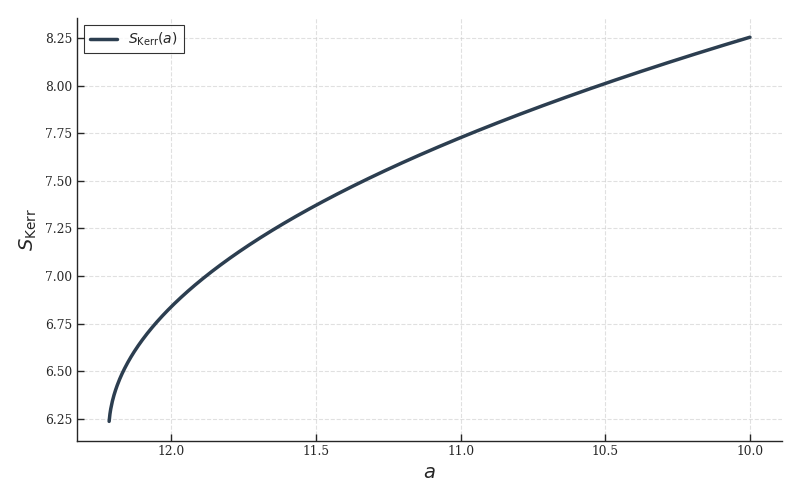

In [13]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,        
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in"      
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.plot(a_prec, ENT, label=r"$S_{\rm Kerr}(a)$", color="#2c3e50", lw=2.5, zorder=2)
ax.invert_xaxis()
ax.set_xlabel(r"$a\ $") 
ax.set_ylabel(r"$S_{\rm Kerr}\ $") 
ax.legend(frameon=True, shadow=False, fancybox=False, edgecolor="black", loc='best')
sns.despine()
plt.tight_layout()
plt.show()

### Padé $[2/1]$ extrapolation of the 1PN entropy curve

In this cell we extrapolate the 1PN entropy curve toward smaller separations using a Padé $[2/1]$ approximant. Starting from the valid 1PN data, we first select only physical points satisfying

$$
a>0,
\qquad
M_{\rm tot}>0,
\qquad
|\chi|\leq 1.
$$

The fitting variable is chosen as

$$
x = \frac{1}{\sqrt{a}},
$$

which increases as the binary separation decreases. Instead of fitting the entropy directly, we fit separately the binding energy

$$
E_{\rm bind}=M_{\rm tot}-m
$$

and the dimensionless Kerr spin parameter

$$
\chi = \frac{J_{\rm tot}}{M_{\rm tot}^2}.
$$

Both quantities are fitted with a Padé $[2/1]$ model,

$$
P_{[2/1]}(x)
=

\frac{a_0+a_1x+a_2x^2}{1+b_1x}.
$$

The fit is performed with a least-squares routine using a `soft_l1` loss. Several initial guesses are tested through a multi-start procedure, and the solution with the smallest cost is retained. The weights are chosen as

$$
\sigma(a)=\left(\frac{a}{a_{\min}}\right),
$$

so that points at smaller separation have larger statistical weight in the fit.

After the extrapolation, the total mass and angular momentum are reconstructed as

$$
M_{\rm extrap}=m+E_{\rm bind}^{\rm extrap},
$$

$$
J_{\rm extrap}
=

\chi_{\rm extrap}
M_{\rm extrap}^2.
$$

The Kerr entropy is then computed from the reconstructed quantities,

$$
S_{\rm Kerr}
=

2\pi M
\left(
M+
\sqrt{
M^2-\frac{J^2}{M^2}
}
\right).
$$

Only physical extrapolated points with $M>0$ and $|\chi|\leq1$ are retained. The maximum of the extrapolated entropy curve defines

$$
a_{\max}^{\rm Padé},
$$

which is then compared with the merger separation predicted by the surrogate model,

$$
a_{\rm merger}^{\rm NR}.
$$

The main diagnostic quantity is therefore

$$
\Delta a
=

\left|
a_{\max}^{\rm Padé}
-

a_{\rm merger}^{\rm NR}
\right|.
$$

This provides a direct test of whether the maximum of the extrapolated entropy curve occurs close to the surrogate merger separation.


In [14]:
valid_mask = (
    np.isfinite(ENT)
    & np.isfinite(a_prec)
    & np.isfinite(E_tot_1PN)
    & np.isfinite(J_tot_1PN)
    & (a_prec > 0)
    & (E_tot_1PN > 0)
)

a_valid = a_prec[valid_mask]
M_valid = E_tot_1PN[valid_mask]
J_valid = J_tot_1PN[valid_mask]
S_valid = ENT[valid_mask]

sort_idx = np.argsort(a_valid)

a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S_valid[sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)

try:
    m_ref = float(m1_num + m2_num)
except NameError:
    m_ref = 1.0

Ebind_fit = M_fit - m_ref
chi_fit = J_fit / M_fit**2

fit_mask = (np.isfinite(x_fit)& np.isfinite(Ebind_fit)& np.isfinite(chi_fit)& (np.abs(chi_fit) <= 1.0))
a_fit = a_fit[fit_mask]
x_fit = x_fit[fit_mask]
M_fit = M_fit[fit_mask]
J_fit = J_fit[fit_mask]
S_fit = S_fit[fit_mask]
Ebind_fit = Ebind_fit[fit_mask]
chi_fit = chi_fit[fit_mask]
a_min_fit = np.nanmin(a_fit)
sigma_fit = (a_fit / a_min_fit)**1.0


def pade_2_1_fit(
    x,
    y,
    sigma,
    y_scale=None,
    n_starts=60,
    random_seed=1234,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=50000,
    progress_label="Padé [2/1] fit"
):
    
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    valid = (np.isfinite(x)& np.isfinite(y)& np.isfinite(sigma)& (sigma > 0))
    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]
    lower_bounds = np.array([-np.inf, -np.inf, -np.inf, 0.0], dtype=float)
    upper_bounds = np.array([ np.inf,  np.inf,  np.inf, np.inf], dtype=float)

    def residuals(params):
        y_model = pade_2_1(x, *params)

        res = (y_model - y) / sigma
        res = np.where(np.isfinite(res), res, 1.0e12)

        return res

    rng = np.random.default_rng(random_seed)
    starts = []
    starts.append(np.array([np.nanmedian(y),0.0,0.0,0.1],dtype=float))

    for _ in range(n_starts - 1):

        starts.append(np.array([np.nanmedian(y),rng.normal(loc=0.0, scale=0.2 * y_scale),rng.normal(loc=0.0, scale=0.2 * y_scale),rng.uniform(low=0.0, high=1.0)],dtype=float))

    best_result = None
    best_cost = np.inf
    last_exception = None
    iterator = tqdm(starts,desc=progress_label,total=len(starts),leave=True)

    for p0 in iterator:

        try:
            res = least_squares(residuals,p0,bounds=(lower_bounds, upper_bounds),loss=loss,f_scale=f_scale,x_scale="jac",max_nfev=max_nfev)

            if res.success and np.isfinite(res.cost) and res.cost < best_cost:
                best_result = res
                best_cost = res.cost

            iterator.set_postfix(best_cost=f"{best_cost:.3e}")

        except Exception as exc:
            last_exception = exc
            iterator.set_postfix(error=str(exc)[:40])
            continue

    if best_result is None:
        raise RuntimeError("fit with Padè 2/1 failed")
    return best_result.x, best_result

model_name = "Padé [2/1]"

N_E_BIND = 20
N_CHI = 20

popt_Ebind, result_Ebind = pade_2_1_fit(
    x=x_fit,
    y=Ebind_fit,
    sigma=sigma_fit,
    y_scale=np.nanstd(Ebind_fit),
    n_starts=N_E_BIND,
    random_seed=1234,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=30000,
    progress_label=r"Fitting E_bind with Padé [2/1]"
)

popt_chi, result_chi = pade_2_1_fit(
    x=x_fit,
    y=chi_fit,
    sigma=sigma_fit,
    y_scale=np.nanstd(chi_fit),
    n_starts=N_CHI,
    random_seed=4321,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=15000,
    progress_label=r"Fitting chi with Padé [2/1]"
)


a_extrap = np.linspace(15.0, 1.0, 10000)
x_extrap = 1.0 / np.sqrt(a_extrap)
Ebind_extrap = pade_2_1(x_extrap, *popt_Ebind)
chi_extrap = pade_2_1(x_extrap, *popt_chi)
M_extrap = m_ref + Ebind_extrap
J_extrap = chi_extrap * M_extrap**2
physical_mask = (np.isfinite(M_extrap)& np.isfinite(chi_extrap)& np.isfinite(J_extrap)& (M_extrap > 0)& (np.abs(chi_extrap) <= 1.0))
ENT_extrap = np.full_like(a_extrap, np.nan, dtype=float)
ENT_extrap[physical_mask] = entropy(M_extrap[physical_mask],J_extrap[physical_mask])

if np.all(np.isnan(ENT_extrap)):
    raise RuntimeError("No physical points identified")

idx_max = np.nanargmax(ENT_extrap)
a_max_entropy = a_extrap[idx_max]
S_max_entropy = ENT_extrap[idx_max]
M_at_max = M_extrap[idx_max]
J_at_max = J_extrap[idx_max]
chi_at_max = chi_extrap[idx_max]
delta_a = np.abs(a_max_entropy - a_merger)

accepted_results = [
    {
        "model": model_name,
        "a_max": a_max_entropy,
        "S_max": S_max_entropy,
        "M_at_max": M_at_max,
        "J_at_max": J_at_max,
        "chi_at_max": chi_at_max,
        "delta_a": delta_a,
        "cost_Ebind": result_Ebind.cost,
        "cost_chi": result_chi.cost,
        "nfev_Ebind": result_Ebind.nfev,
        "nfev_chi": result_chi.nfev
    }
]

pade_curves = {
    model_name: {
        "a_extrap": a_extrap,
        "x_extrap": x_extrap,
        "Ebind_extrap": Ebind_extrap,
        "M_extrap": M_extrap,
        "J_extrap": J_extrap,
        "chi_extrap": chi_extrap,
        "ENT_extrap": ENT_extrap,
        "popt_Ebind": popt_Ebind,
        "popt_chi": popt_chi,
        "result_Ebind": result_Ebind,
        "result_chi": result_chi,
        "physical_mask": physical_mask
    }
}

print(f"Maximum with Padé [2/1] at a  = {a_max_entropy:.6f}")
print(f"S_max                         = {S_max_entropy:.10f}")
print(f"M_tot at maximum              = {M_at_max:.10f}")
print(f"J_tot at maximum              = {J_at_max:.10f}")
print(f"chi at maximum                = {chi_at_max:.10f}")
print(f"NR Merger a                   = {a_merger:.6f}")
print(f"Delta a                       = {delta_a:.6f}")

Fitting E_bind with Padé [2/1]:   0%|          | 0/20 [00:00<?, ?it/s]

Fitting chi with Padé [2/1]:   0%|          | 0/20 [00:00<?, ?it/s]

Maximum with Padé [2/1] at a  = 3.055406
S_max                         = 9.9136133792
M_tot at maximum              = 0.9785598857
J_tot at maximum              = 0.7295780708
chi at maximum                = 0.7618982120
NR Merger a                   = 3.116268
Delta a                       = 0.060863


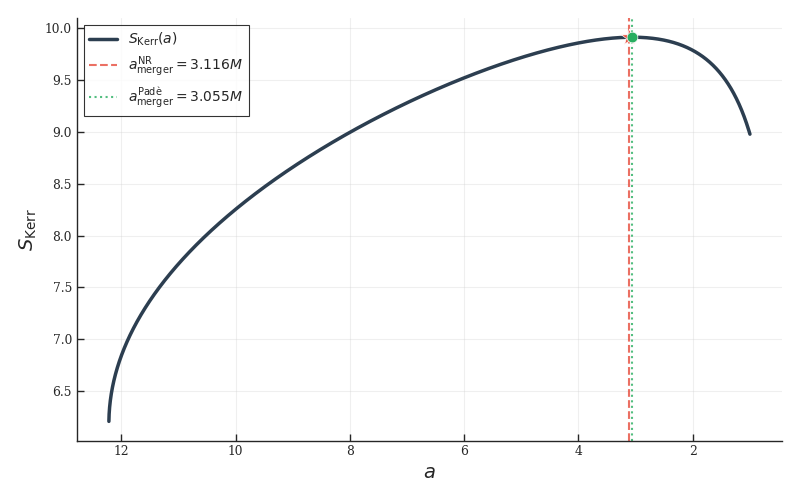

In [15]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

sort_idx = np.argsort(a_extrap)
a_sorted = a_extrap[sort_idx]
ent_sorted = ENT_extrap[sort_idx]
y_at_merger = np.interp(a_merger, a_sorted, ent_sorted)
y_at_max_entropy = np.interp(a_max_entropy, a_sorted, ent_sorted)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_extrap, ENT_extrap, label=r"$S_{\rm Kerr}(a)$", color="#2c3e50", lw=2.5)
ax.scatter(a_merger, y_at_merger, marker='*', s=150, color='#e74c3c', zorder=5, edgecolor='white', linewidth=0.5)
ax.scatter(a_max_entropy, y_at_max_entropy, marker='o', s=60, color='#27ae60', zorder=5, edgecolor='white', linewidth=0.5)
ax.axvline(a_merger, color="#e74c3c", linestyle="--", lw=1.5, alpha=0.8, 
           label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax.axvline(a_max_entropy, color="#27ae60", linestyle=":", lw=1.5, alpha=0.8, 
           label=fr"$a_{{\rm merger}}^{{\rm Padè}}={a_max_entropy:.3f}M$")
ax.invert_xaxis()
ax.set_xlabel(r"$a$") 
ax.set_ylabel(r"$S_{\rm Kerr}$")           
ax.legend(frameon=True, shadow=False, fancybox=False, edgecolor="black", loc='best')
sns.despine()
plt.tight_layout()
plt.show()